timed writeups \
no help\
starting over if i check\
numpy attempt 1: 30 seconds, didn't get past imports \
numpy attempt 2: 8min47, choked at getting a random matrix. also forgot to scale \
numpy attempt 3: 6min46, had to stop because of cooking, didn't do scaling well \
numpy attempt 4: 11min47, didn't know how to write sigmoid, loss inputs, b2 being (1,output_size) \
numpy attempt 5: 17min59, confused on derivatives in backward(), forgot learning rate, using * for matmuls, stopped at writing training loop \
numpy attempt 6: 32min49, finished (but broken) implemententation. bad dimension handling for backward(), and using X.forward instead of self.forward. was treating X like a scalar instead of understanding how batch dimension works \
numpy attempt 7: 18min23, iterating through layers wrong, small mistakes here and there \
numpy attempt 8: 18min41, mostly correct, stopping here because diminishing returns and rest can be fixed from standard debugging



In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [192]:
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

In [193]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1-x)

In [ ]:
class MLP:

    def __init__(self, layer_sizes):
        self.weights = []
        self.biases = []
        for i in range(len(layer_sizes) - 1):
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]))
            self.biases.append(np.random.randn(1, layer_sizes[i+1]))

    def forward(self, X):
        self.a_values = [X]
        self.z_values = []
        a = X
        for w, b in zip(self.weights, self.biases):
            z = np.dot(a, w) + b
            a = sigmoid(z)
            self.a_values.append(a)
            self.z_values.append(z)

        return self.a_values[-1]

    def backward(self, X, y, output, lr):
        batch_size = X.shape[0]
        n_layers = len(self.weights)
        dL = 2 * (output - y)
        dydz = sigmoid_deriv(self.a_values[-1])
        combined = dL * dydz
        grad_w = [None] * n_layers
        grad_b = [None] * n_layers

        for layer in reversed(range(n_layers)):
            a_prev = self.a_values[layer]
            grad_w[layer] = np.dot(a_prev.T, combined) / batch_size
            grad_b[layer] = np.sum(combined, axis=0, keepdims=True) / batch_size
            if layer > 0:
                w = self.weights[layer]
                dydz = sigmoid_deriv(self.a_values[layer])
                combined = np.dot(combined, w.T) * dydz
            self.weights[layer] -= lr * grad_w[layer]
            self.biases[layer] -= lr * grad_b[layer]


    def train(self, X, y, epochs, lr):
        losses = []
        for i in range(epochs):
            output = self.forward(X)
            loss = np.mean((output - y)**2)
            losses.append(loss)
            if i % 10 == 0:
                print("loss is: ", loss)
            self.backward(X, y, output, lr)
        return losses

loss is:  0.4614013806407368
loss is:  0.45802603740221765
loss is:  0.4540572129873124
loss is:  0.44933802821211977
loss is:  0.4436579236340678
loss is:  0.43673196881555576
loss is:  0.4281736951182239
loss is:  0.41746393354595285
loss is:  0.40392873890373965
loss is:  0.3867675357935349
loss is:  0.3652297063291256
loss is:  0.3390943683157613
loss is:  0.3094652287780342
loss is:  0.2792314211945661
loss is:  0.25203368631922246
loss is:  0.23015692613419125
loss is:  0.21367796953191323
loss is:  0.20139678625783233
loss is:  0.19196582130873402
loss is:  0.18437078438072818
loss is:  0.1779618412521909
loss is:  0.1723505788079106
loss is:  0.16731001659690922
loss is:  0.16270659492372752
loss is:  0.15845931221668713
loss is:  0.15451645996495544
loss is:  0.15084270496888952
loss is:  0.14741200289228285
loss is:  0.1442037326650738
loss is:  0.14120059143182548
loss is:  0.13838744569148406
loss is:  0.13575069913672272
loss is:  0.1332779382926598
loss is:  0.13095772667

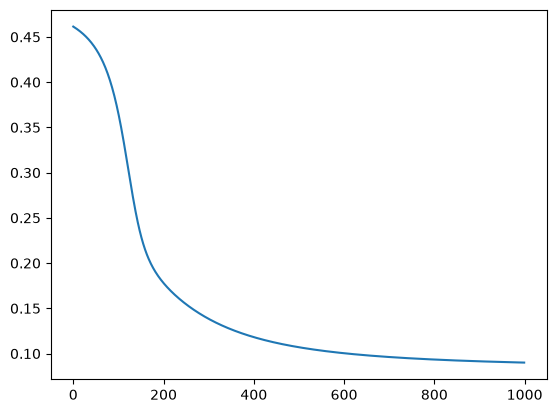

In [208]:
input_size, hidden_size, output_size = 2, 4, 1
model = MLP([input_size, hidden_size, output_size])
losses = model.train(X_train, y_train, epochs=1000, lr=0.1)
plt.plot(losses)